# Augmented vs Base Image Viewer

This notebook compares each generated image with its base image from the same folder.

- Left: augmented image with pasted objects highlighted
- Right: base image with the pasted objects outlined as the difference

It expects an `augmented_dataset/train/` folder that contains images, labels, and metadata files.

In [2]:
import json
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# PROJECT_ROOT = Path('/home/khanh/Projects/DifficultyAgri')
# AUGMENTED_DATASET_ROOT = PROJECT_ROOT / 'results' / '055_multiseed_copy_paste_exp' / 'seed_123' / 'Step_4_Copy_Paste_Augmentation' / 'augmented_dataset'
# SPLIT = 'train'
IMAGE_EXTS = ['.jpg', '.jpeg', '.png']

# images_dir = AUGMENTED_DATASET_ROOT / SPLIT / 'images'
# labels_dir = AUGMENTED_DATASET_ROOT / SPLIT / 'labels'
# metadata_dir = AUGMENTED_DATASET_ROOT / SPLIT / 'metadata'

AUGMENTED_DATASET_ROOT = Path('/home/khanh/Projects/DifficultyAgri/results/13_multiseed_score_vs_noscore_copy_paste_exp_global_wheat_head/seed_123/Step_4_Copy_Paste_Augmentation/with_score/augmented_dataset')
# AUGMENTED_DATASET_ROOT = Path('/home/khanh/Projects/DifficultyAgri/results/12_multiseed_score_vs_noscore_copy_paste_exp_apple_withaug/seed_123/Step_4_Copy_Paste_Augmentation/with_score/augmented_dataset')
AUGMENTED_DATASET_ROOT = Path('/home/khanh/Projects/DifficultyAgri/results/055_multiseed_copy_paste_exp_wgisd_boundary_high/seed_123/Step_4_Copy_Paste_Augmentation/augmented_dataset')
images_dir = AUGMENTED_DATASET_ROOT / 'train' / 'images'
labels_dir = AUGMENTED_DATASET_ROOT / 'train' / 'labels'
metadata_dir = AUGMENTED_DATASET_ROOT / 'train' / 'metadata'

for path in [images_dir, labels_dir, metadata_dir]:
    if not path.exists():
        raise FileNotFoundError(f'Missing required directory: {path}')

print('Augmented dataset root:', AUGMENTED_DATASET_ROOT)
print('Images dir:', images_dir)
print('Labels dir:', labels_dir)
print('Metadata dir:', metadata_dir)

Augmented dataset root: /home/khanh/Projects/DifficultyAgri/results/055_multiseed_copy_paste_exp_wgisd_boundary_high/seed_123/Step_4_Copy_Paste_Augmentation/augmented_dataset
Images dir: /home/khanh/Projects/DifficultyAgri/results/055_multiseed_copy_paste_exp_wgisd_boundary_high/seed_123/Step_4_Copy_Paste_Augmentation/augmented_dataset/train/images
Labels dir: /home/khanh/Projects/DifficultyAgri/results/055_multiseed_copy_paste_exp_wgisd_boundary_high/seed_123/Step_4_Copy_Paste_Augmentation/augmented_dataset/train/labels
Metadata dir: /home/khanh/Projects/DifficultyAgri/results/055_multiseed_copy_paste_exp_wgisd_boundary_high/seed_123/Step_4_Copy_Paste_Augmentation/augmented_dataset/train/metadata


In [3]:
def find_image_path(stem: str, search_dir: Path) -> Path | None:
    for ext in IMAGE_EXTS:
        candidate = search_dir / f'{stem}{ext}'
        if candidate.exists():
            return candidate
    return None

def load_metadata(metadata_path: Path) -> dict:
    with open(metadata_path, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_yolo_boxes(label_path: Path):
    boxes = []
    if not label_path.exists():
        return boxes
    with open(label_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            boxes.append({
                'class_id': int(float(parts[0])),
                'x_center': float(parts[1]),
                'y_center': float(parts[2]),
                'width': float(parts[3]),
                'height': float(parts[4]),
            })
    return boxes

def yolo_to_xyxy(box, width_px: int, height_px: int):
    xc = box['x_center'] * width_px
    yc = box['y_center'] * height_px
    bw = box['width'] * width_px
    bh = box['height'] * height_px
    x1 = max(0, int(round(xc - bw / 2)))
    y1 = max(0, int(round(yc - bh / 2)))
    x2 = min(width_px - 1, int(round(xc + bw / 2)))
    y2 = min(height_px - 1, int(round(yc + bh / 2)))
    return x1, y1, x2, y2

def draw_boxes(image: Image.Image, boxes, color: str, width: int = 4, label_prefix: str = ''):
    img = image.copy().convert('RGB')
    draw = ImageDraw.Draw(img)
    font = ImageFont.load_default()
    w_px, h_px = img.size
    for box in boxes:
        x1, y1, x2, y2 = yolo_to_xyxy(box, w_px, h_px)
        draw.rectangle([x1, y1, x2, y2], outline=color, width=width)
        label = f"{label_prefix}{box['class_id']}"
        text_bbox = draw.textbbox((0, 0), label, font=font)
        text_w = text_bbox[2] - text_bbox[0]
        text_h = text_bbox[3] - text_bbox[1]
        pad = 2
        top = max(0, y1 - text_h - 2 * pad - 1)
        draw.rectangle([x1, top, x1 + text_w + 2 * pad, y1], fill=color)
        draw.text((x1 + pad, top + pad), label, fill='white', font=font)
    return img

def collect_samples() -> pd.DataFrame:
    rows = []
    for metadata_path in sorted(metadata_dir.glob('aug_*.json')):
        meta = load_metadata(metadata_path)
        aug_stem = metadata_path.stem
        base_stem = Path(meta.get('background_image_name', '')).stem
        if not base_stem:
            continue
        aug_image_path = find_image_path(aug_stem, images_dir)
        base_image_path = find_image_path(base_stem, images_dir)
        if aug_image_path is None or base_image_path is None:
            continue
        rows.append({
            'aug_name': aug_stem,
            'base_name': base_stem,
            'metadata_path': metadata_path,
            'aug_image_path': aug_image_path,
            'base_image_path': base_image_path,
            'aug_label_path': labels_dir / f'{aug_stem}.txt',
            'base_label_path': labels_dir / f'{base_stem}.txt',
            'pasted_object_count': int(meta.get('pasted_object_count', 0)),
            'selected_object_count': int(meta.get('selected_object_count', 0)),
            'use_score_guidance': bool(meta.get('use_score_guidance', False)),
            'score_alpha': float(meta.get('score_alpha', 0.0)),
        })
    return pd.DataFrame(rows)

samples_df = collect_samples()
print(f'Found {len(samples_df)} augmented samples')
samples_df.head(10)

Found 57 augmented samples


,aug_name,base_name,metadata_path,aug_image_path,base_image_path,aug_label_path,base_label_path,pasted_object_count,selected_object_count,use_score_guidance,score_alpha
0,aug_0001_SYH_2017-04-27_1316,SYH_2017-04-27_1316,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,4,4,True,3.0
1,aug_0002_SVB_1973,SVB_1973,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,8,8,True,3.0
2,aug_0003_CFR_1652,CFR_1652,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,2,2,True,3.0
3,aug_0004_SVB_20180427_151832492,SVB_20180427_151832492,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,4,4,True,3.0
4,aug_0005_CDY_2024,CDY_2024,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,8,8,True,3.0
5,aug_0006_CDY_2024,CDY_2024,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,2,2,True,3.0
6,aug_0007_CDY_2061,CDY_2061,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,8,8,True,3.0
7,aug_0008_CDY_20180427_153433120_BURST001,CDY_20180427_153433120_BURST001,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,2,2,True,3.0
8,aug_0009_CFR_1662,CFR_1662,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,5,5,True,3.0
9,aug_0010_CSV_1901,CSV_1901,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,/home/khanh/Projects/DifficultyAgri/results/05...,6,6,True,3.0


Default sample: aug_0002_SVB_1973


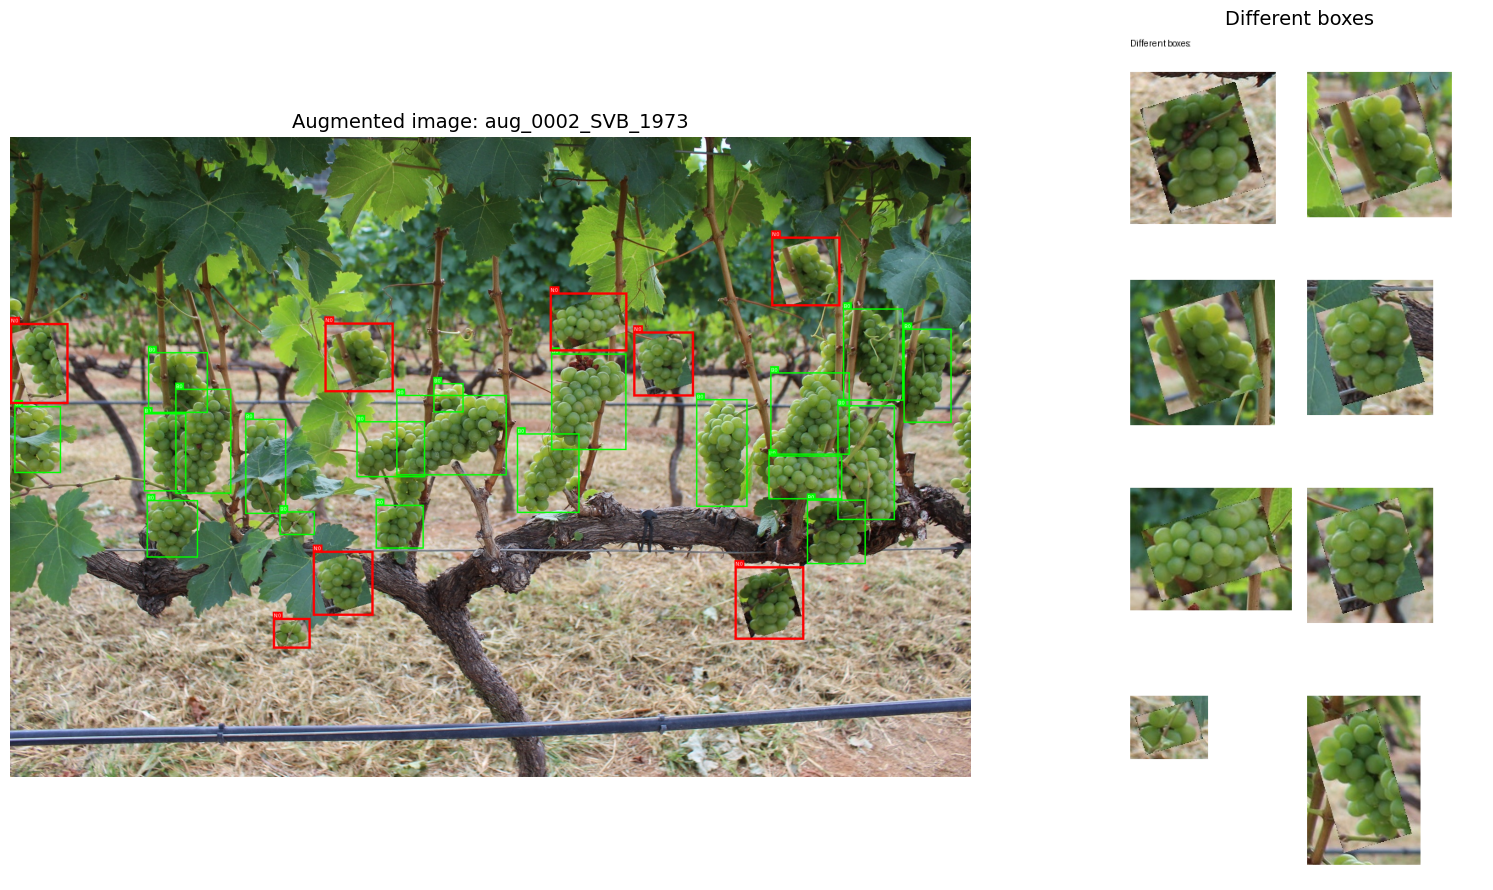

,aug_name,base_name,pasted_object_count,selected_object_count,use_score_guidance,score_alpha,pasted_boxes
0,aug_0002_SVB_1973,SVB_1973,8,8,True,3.0,8


In [4]:
def show_comparison(sample_name: str):
    if samples_df.empty:
        raise ValueError('No augmented samples were found.')
    row = samples_df.loc[samples_df['aug_name'] == sample_name]
    if row.empty:
        raise ValueError(f'Unknown sample: {sample_name}')

    sample = row.iloc[0]
    meta = load_metadata(sample['metadata_path'])
    aug_img = Image.open(sample['aug_image_path']).convert('RGB')
    base_label_boxes = load_yolo_boxes(sample['base_label_path'])
    pasted_boxes = [
        {
            'class_id': int(b['class_id']),
            'x_center': float(b['x_center']),
            'y_center': float(b['y_center']),
            'width': float(b['width']),
            'height': float(b['height']),
        }
        for b in meta.get('pasted_boxes', [])
    ]

    def crop_box(image: Image.Image, box: dict, padding: float = 0.08) -> Image.Image:
        width_px, height_px = image.size
        x1, y1, x2, y2 = yolo_to_xyxy(box, width_px, height_px)
        box_w = max(1, x2 - x1)
        box_h = max(1, y2 - y1)
        pad_x = int(round(box_w * padding))
        pad_y = int(round(box_h * padding))
        crop_left = max(0, x1 - pad_x)
        crop_top = max(0, y1 - pad_y)
        crop_right = min(width_px, x2 + pad_x)
        crop_bottom = min(height_px, y2 + pad_y)
        return image.crop((crop_left, crop_top, crop_right, crop_bottom)).convert('RGB')

    def build_difference_panel(image: Image.Image, boxes: list[dict]) -> Image.Image:
        if not boxes:
            return Image.new('RGB', image.size, color='white')
        crops = [crop_box(image, box) for box in boxes]
        max_width = max(crop.size[0] for crop in crops)
        max_height = max(crop.size[1] for crop in crops)
        cols = 2 if len(crops) > 1 else 1
        rows = (len(crops) + cols - 1) // cols
        gap = 18
        title_h = 28
        canvas_width = cols * max_width + (cols + 1) * gap
        canvas_height = rows * (max_height + title_h) + (rows + 1) * gap
        canvas = Image.new('RGB', (canvas_width, canvas_height), color='white')
        draw = ImageDraw.Draw(canvas)
        font = ImageFont.load_default()
        draw.text((gap, 6), 'Different boxes:', fill='black', font=font)
        for index, crop in enumerate(crops):
            row_idx = index // cols
            col_idx = index % cols
            x = gap + col_idx * (max_width + gap)
            y = gap + row_idx * (max_height + title_h + gap)
            canvas.paste(crop, (x, y + title_h))
        return canvas

    augmented_view = draw_boxes(aug_img, base_label_boxes, color='lime', width=3, label_prefix='B:')
    augmented_view = draw_boxes(augmented_view, pasted_boxes, color='red', width=5, label_prefix='N:')
    difference_panel = build_difference_panel(aug_img, pasted_boxes)

    fig, axes = plt.subplots(1, 2, figsize=(18, 9))
    axes[0].imshow(augmented_view)
    axes[0].set_title(f"Augmented image: {sample['aug_name']}")
    axes[0].axis('off')

    axes[1].imshow(difference_panel)
    axes[1].set_title('Different boxes')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    display(pd.DataFrame([
        {
            'aug_name': sample['aug_name'],
            'base_name': sample['base_name'],
            'pasted_object_count': sample['pasted_object_count'],
            'selected_object_count': sample['selected_object_count'],
            'use_score_guidance': sample['use_score_guidance'],
            'score_alpha': sample['score_alpha'],
            'pasted_boxes': len(pasted_boxes),
        }
    ]))

default_sample = None if samples_df.empty else samples_df.sort_values(['pasted_object_count', 'aug_name'], ascending=[False, True]).iloc[0]['aug_name']
print('Default sample:', default_sample)
if default_sample is not None:
    show_comparison(default_sample)

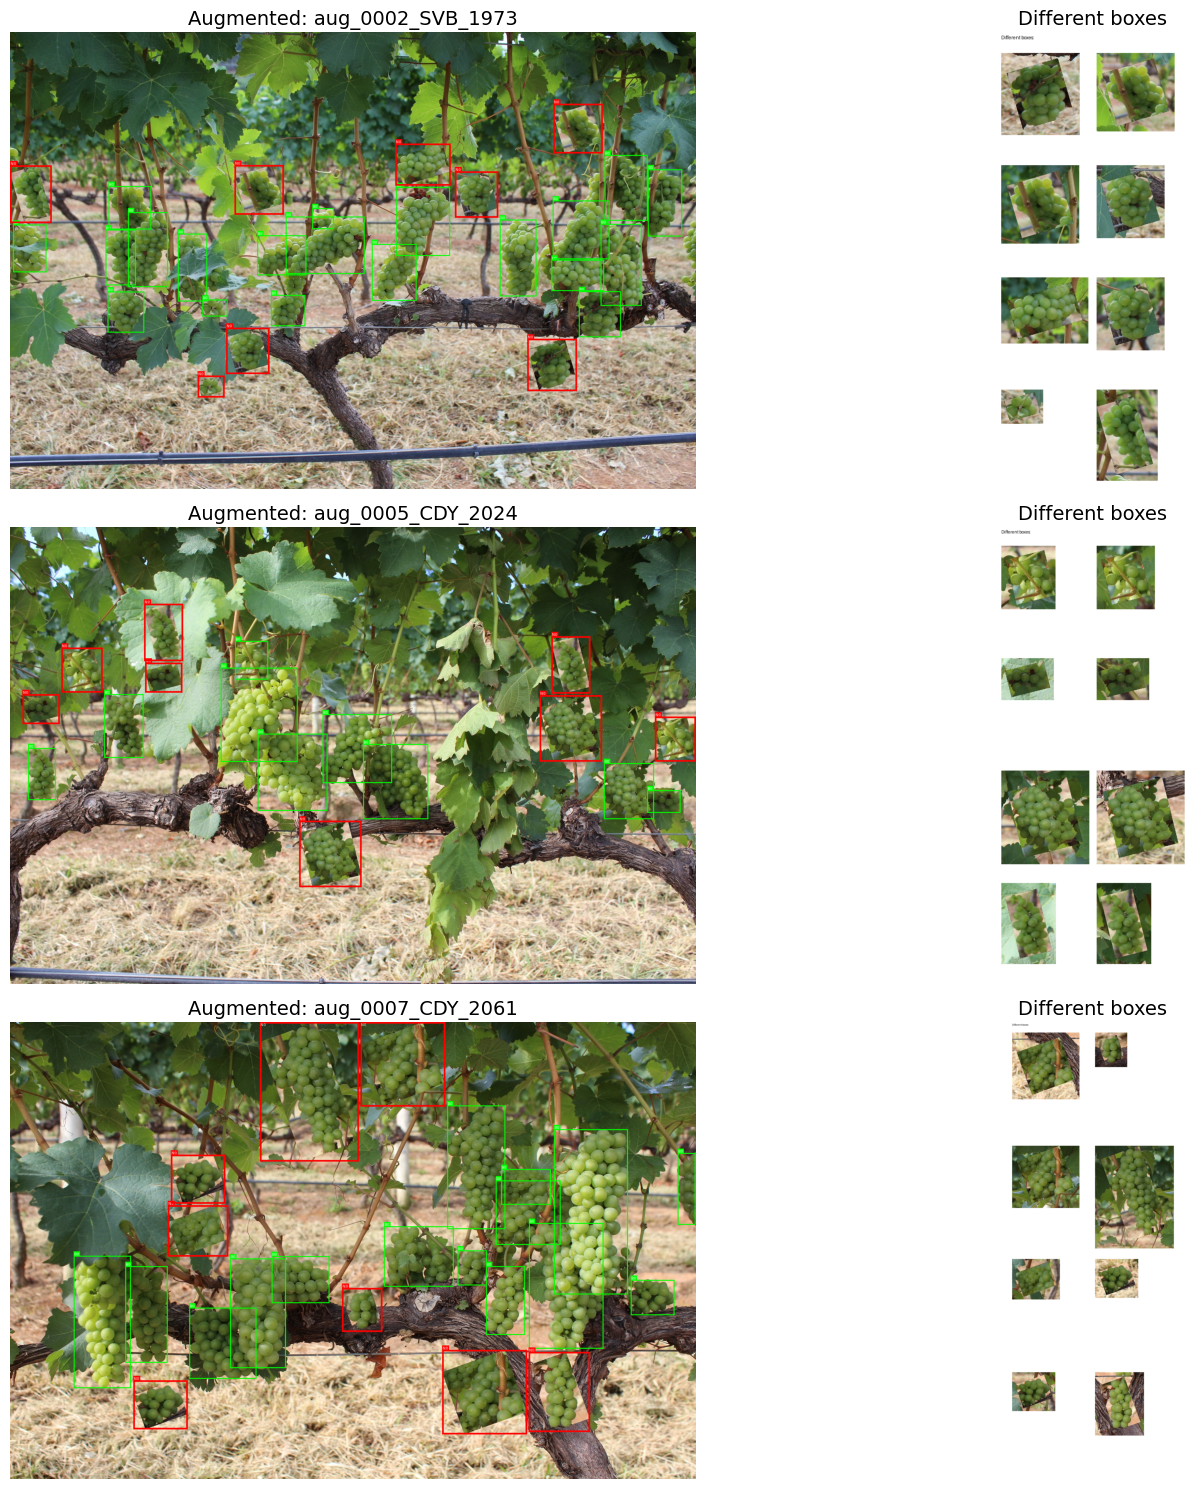

In [5]:
def show_gallery(n: int = 4):
    if samples_df.empty:
        print('No samples to display.')
        return
    rows = samples_df.sort_values(['pasted_object_count', 'aug_name'], ascending=[False, True]).head(n)
    fig, axes = plt.subplots(len(rows), 2, figsize=(18, 5 * len(rows)))
    if len(rows) == 1:
        axes = [axes]
    for ax_row, (_, sample) in zip(axes, rows.iterrows()):
        meta = load_metadata(sample['metadata_path'])
        aug_img = Image.open(sample['aug_image_path']).convert('RGB')
        base_label_boxes = load_yolo_boxes(sample['base_label_path'])
        pasted_boxes = [
            {
                'class_id': int(b['class_id']),
                'x_center': float(b['x_center']),
                'y_center': float(b['y_center']),
                'width': float(b['width']),
                'height': float(b['height']),
            }
            for b in meta.get('pasted_boxes', [])
        ]

        def crop_box(image: Image.Image, box: dict, padding: float = 0.08) -> Image.Image:
            width_px, height_px = image.size
            x1, y1, x2, y2 = yolo_to_xyxy(box, width_px, height_px)
            box_w = max(1, x2 - x1)
            box_h = max(1, y2 - y1)
            pad_x = int(round(box_w * padding))
            pad_y = int(round(box_h * padding))
            crop_left = max(0, x1 - pad_x)
            crop_top = max(0, y1 - pad_y)
            crop_right = min(width_px, x2 + pad_x)
            crop_bottom = min(height_px, y2 + pad_y)
            return image.crop((crop_left, crop_top, crop_right, crop_bottom)).convert('RGB')

        def build_difference_panel(image: Image.Image, boxes: list[dict]) -> Image.Image:
            if not boxes:
                return Image.new('RGB', image.size, color='white')
            crops = [crop_box(image, box) for box in boxes]
            max_width = max(crop.size[0] for crop in crops)
            max_height = max(crop.size[1] for crop in crops)
            cols = 2 if len(crops) > 1 else 1
            rows = (len(crops) + cols - 1) // cols
            gap = 18
            title_h = 28
            canvas_width = cols * max_width + (cols + 1) * gap
            canvas_height = rows * (max_height + title_h) + (rows + 1) * gap
            canvas = Image.new('RGB', (canvas_width, canvas_height), color='white')
            draw = ImageDraw.Draw(canvas)
            font = ImageFont.load_default()
            draw.text((gap, 6), 'Different boxes:', fill='black', font=font)
            for index, crop in enumerate(crops):
                row_idx = index // cols
                col_idx = index % cols
                x = gap + col_idx * (max_width + gap)
                y = gap + row_idx * (max_height + title_h + gap)
                canvas.paste(crop, (x, y + title_h))
            return canvas

        augmented_view = draw_boxes(aug_img, base_label_boxes, color='lime', width=3, label_prefix='B:')
        augmented_view = draw_boxes(augmented_view, pasted_boxes, color='red', width=5, label_prefix='N:')
        difference_panel = build_difference_panel(aug_img, pasted_boxes)

        ax_row[0].imshow(augmented_view)
        ax_row[0].set_title(f"Augmented: {sample['aug_name']}")
        ax_row[0].axis('off')

        ax_row[1].imshow(difference_panel)
        ax_row[1].set_title('Different boxes')
        ax_row[1].axis('off')

    plt.tight_layout()
    plt.show()

show_gallery(3)

## Frequency Analysis

This section answers:
1. In each augmented image, how many objects were pasted?
2. Across all augmented images, how often each source image was used as background?

In [6]:
# Collect metadata for all augmented samples
meta_rows = []
for meta_path in sorted(metadata_dir.glob('aug_*.json')):
    meta = load_metadata(meta_path)
    bg_name = meta.get('background_image_name', '')
    bg_stem = Path(bg_name).stem if bg_name else ''
    pasted_count = int(meta.get('pasted_object_count', 0))

    meta_rows.append(
        {
            'aug_name': meta_path.stem,
            'background_name': bg_name,
            'background_stem': bg_stem,
            'pasted_object_count': pasted_count,
            'selected_object_count': int(meta.get('selected_object_count', 0)),
        }
    )

freq_df = pd.DataFrame(meta_rows)
print(f'Total augmented images: {len(freq_df)}')
freq_df.head(10)

Total augmented images: 57


,aug_name,background_name,background_stem,pasted_object_count,selected_object_count
0,aug_0001_SYH_2017-04-27_1316,SYH_2017-04-27_1316.jpg,SYH_2017-04-27_1316,4,4
1,aug_0002_SVB_1973,SVB_1973.jpg,SVB_1973,8,8
2,aug_0003_CFR_1652,CFR_1652.jpg,CFR_1652,2,2
3,aug_0004_SVB_20180427_151832492,SVB_20180427_151832492.jpg,SVB_20180427_151832492,4,4
4,aug_0005_CDY_2024,CDY_2024.jpg,CDY_2024,8,8
5,aug_0006_CDY_2024,CDY_2024.jpg,CDY_2024,2,2
6,aug_0007_CDY_2061,CDY_2061.jpg,CDY_2061,8,8
7,aug_0008_CDY_20180427_153433120_BURST001,CDY_20180427_153433120_BURST001.jpg,CDY_20180427_153433120_BURST001,2,2
8,aug_0009_CFR_1662,CFR_1662.jpg,CFR_1662,5,5
9,aug_0010_CSV_1901,CSV_1901.jpg,CSV_1901,6,6


Frequency: number of pasted objects per augmented image


,pasted_object_count,num_augmented_images,fraction
0,2,8,0.140351
1,3,3,0.052632
2,4,10,0.175439
3,5,5,0.087719
4,6,13,0.228070
5,7,6,0.105263
6,8,12,0.210526


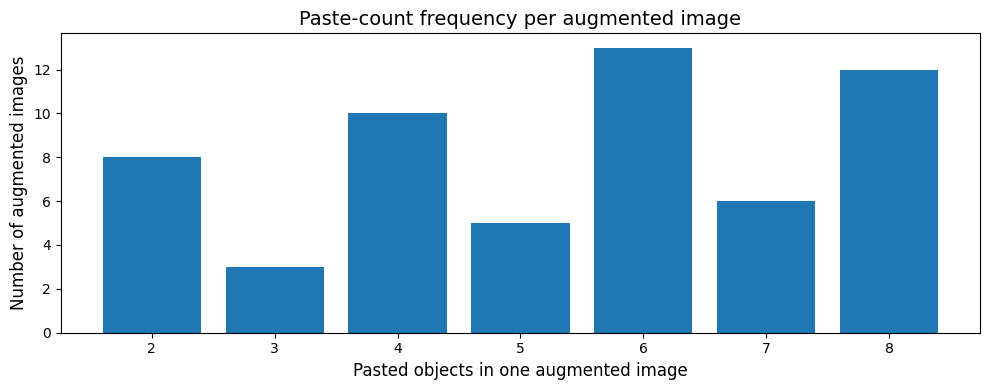

In [7]:
# 1) Frequency of pasted-object count per augmented image
paste_count_freq = (
    freq_df['pasted_object_count']
    .value_counts()
    .sort_index()
    .rename_axis('pasted_object_count')
    .reset_index(name='num_augmented_images')
)

paste_count_freq['fraction'] = paste_count_freq['num_augmented_images'] / max(len(freq_df), 1)
print('Frequency: number of pasted objects per augmented image')
display(paste_count_freq)

plt.figure(figsize=(10, 4))
plt.bar(paste_count_freq['pasted_object_count'], paste_count_freq['num_augmented_images'])
plt.xlabel('Pasted objects in one augmented image')
plt.ylabel('Number of augmented images')
plt.title('Paste-count frequency per augmented image')
plt.tight_layout()
plt.show()


## Object Frequency Table

This table shows how many augmented images each source object appears in.

In [8]:
meta_rows = []
for meta_path in sorted(metadata_dir.glob('aug_*.json')):
    meta = load_metadata(meta_path)
    aug_name = meta_path.stem
    for obj in meta.get('selected_objects', []):
        meta_rows.append(
            {
                'source_image_name': obj.get('source_image_name', ''),
                'source_object_index': int(obj.get('source_object_index', -1)),
                'source_image_path': obj.get('source_image_path', ''),
                'class_id': int(obj.get('class_id', -1)),
                'aug_name': aug_name,
            }
        )

object_appearance_df = pd.DataFrame(meta_rows)
if object_appearance_df.empty:
    object_freq_df = pd.DataFrame(
        columns=[
            'source_image_name',
            'source_object_index',
            'source_image_path',
            'class_id',
            'num_augmented_images_appeared',
            'total_selected_times',
        ]
    )
else:
    object_freq_df = (
        object_appearance_df.groupby(
            ['source_image_name', 'source_object_index', 'source_image_path', 'class_id'],
            as_index=False,
        )
        .agg(
            num_augmented_images_appeared=('aug_name', 'nunique'),
            total_selected_times=('aug_name', 'size'),
        )
        .sort_values(
            ['num_augmented_images_appeared', 'total_selected_times', 'source_image_name', 'source_object_index'],
            ascending=[False, False, True, True],
        )
        .reset_index(drop=True)
    )

print(f'Unique source objects: {len(object_freq_df)}')
display(object_freq_df)


Unique source objects: 215


,source_image_name,source_object_index,source_image_path,class_id,num_augmented_images_appeared,total_selected_times
0,CDY_2029.jpg,1,/home/khanh/Projects/DifficultyAgri/datasets/w...,0,2,2
1,CFR_1670.jpg,7,/home/khanh/Projects/DifficultyAgri/datasets/w...,0,2,2
2,CFR_1670.jpg,14,/home/khanh/Projects/DifficultyAgri/datasets/w...,0,2,2
3,CSV_1890.jpg,9,/home/khanh/Projects/DifficultyAgri/datasets/w...,0,2,2
4,CSV_1890.jpg,16,/home/khanh/Projects/DifficultyAgri/datasets/w...,0,2,2
...,...,...,...,...,...,...
210,SYH_2017-04-27_1311.jpg,14,/home/khanh/Projects/DifficultyAgri/datasets/w...,0,1,1
211,SYH_2017-04-27_1316.jpg,6,/home/khanh/Projects/DifficultyAgri/datasets/w...,0,1,1
212,SYH_2017-04-27_1316.jpg,8,/home/khanh/Projects/DifficultyAgri/datasets/w...,0,1,1
213,SYH_2017-04-27_1316.jpg,15,/home/khanh/Projects/DifficultyAgri/datasets/w...,0,1,1
